## Caso 2 - Camara de Homogeneizacao

Este notebook reproduz a simulacao de Monte Carlo do Caso 2 do artigo `Monte Carlo Simulations as an Alternative for Solving Engineering Problems in Environmental Sciences: Three Case Studies`.

O objetivo e estimar o volume necessario de uma camara de homogeneizacao em uma usina de tratamento de residuos solidos.

In [1]:
!pip install numpy
!pip install matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\eduar\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\eduar\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


### Modelo do artigo

Para cada caminhao, o volume enviado para a camara e calculado por:

`Vi = Vtruck*(1-Esorting/100)*(1-(Mo/100)*(Escreening/100))`

O volume da camara considera o acumulo de tres dias e limite de operacao de 90%:

`Vchamber = (Vday1 + Vday2 + Vday3)/0.90`

### Parametros da simulacao

As distribuicoes usadas seguem o Caso 2 do artigo:

- caminhoes tipo A: `10 m3`, probabilidade `20%`
- caminhoes tipo B: `7 m3`, probabilidade `20%`
- caminhoes tipo C: `3 m3`, probabilidade `60%`
- eficiencia da triagem: `U(5,10)%`
- materia organica: `U(60,70)%`
- eficiencia da peneiracao: `U(90,95)%`
- chegadas dos caminhoes: distribuicao exponencial com taxa `1 caminhao/h`, conforme descrito no artigo

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N=1000
repeticoes=10
dias=3
tempo_operacao=8
taxa_chegada=1

volume_artigo_tabela=94.71
volume_artigo_resumo=94.84

print("numero de iteracoes",N)
print("numero de repeticoes",repeticoes)
print("taxa de chegada usada",taxa_chegada,"caminhao/h")

numero de iteracoes 1000
numero de repeticoes 10
taxa de chegada usada 1 caminhao/h


### Cenarios deterministicos da Tabela 3

O artigo compara o Monte Carlo com tres cenarios deterministicos: minimo, intermediario e maximo.

In [3]:
Vmin=8*3*(3*(1-10/100)*(1-(70/100)*(95/100)))/0.90
Vint=8*3*(7*(1-7.5/100)*(1-(65/100)*(92.5/100)))/0.90
Vmax=8*3*(10*(1-5/100)*(1-(60/100)*(90/100)))/0.90

print("volume minimo",Vmin)
print("volume intermediario",Vint)
print("volume maximo",Vmax)

volume minimo 24.120000000000005
volume intermediario 68.85083333333333
volume maximo 116.5333333333333


### Simulacao de um dia

Esta parte gera um dia de operacao para mostrar as variaveis aleatorias do processo.

In [4]:
tempo=0
tempo_chegada=np.array([0])
volume_descarga=np.array([])

u=np.random.uniform(0,1)
if u<=0.20:
    Vtruck=10
elif u<=0.40:
    Vtruck=7
else:
    Vtruck=3

Esorting=np.random.uniform(5,10)
Mo=np.random.uniform(60,70)
Escreening=np.random.uniform(90,95)
Vi=Vtruck*(1-Esorting/100)*(1-(Mo/100)*(Escreening/100))
volume_descarga=np.append(volume_descarga,Vi)

while tempo<=tempo_operacao:
    p=np.random.uniform(0,1)
    tempo=tempo-np.log(1-p)/taxa_chegada

    if tempo<=tempo_operacao:
        u=np.random.uniform(0,1)
        if u<=0.20:
            Vtruck=10
        elif u<=0.40:
            Vtruck=7
        else:
            Vtruck=3

        Esorting=np.random.uniform(5,10)
        Mo=np.random.uniform(60,70)
        Escreening=np.random.uniform(90,95)
        Vi=Vtruck*(1-Esorting/100)*(1-(Mo/100)*(Escreening/100))

        tempo_chegada=np.append(tempo_chegada,tempo)
        volume_descarga=np.append(volume_descarga,Vi)

print("tempos de chegada")
print(tempo_chegada)
print("volumes enviados para a camara")
print(volume_descarga)
print("numero de caminhoes no dia",len(volume_descarga))

tempos de chegada
[0.         0.16962487 1.40087493 1.60155392 1.94577691 2.5547116
 2.60227545 5.97290579 6.55299664 6.85245441 7.05684301 7.96789742]
volumes enviados para a camara
[2.3624602  3.4228738  3.40612012 3.7268146  1.19438203 1.1122929
 1.20142457 1.20682934 3.97362458 1.10832095 0.94148797 1.2508839 ]
numero de caminhoes no dia 12


### Figura parecida com a Figura 9

A figura abaixo mostra o volume enviado para a camara ao longo de um dia simulado.

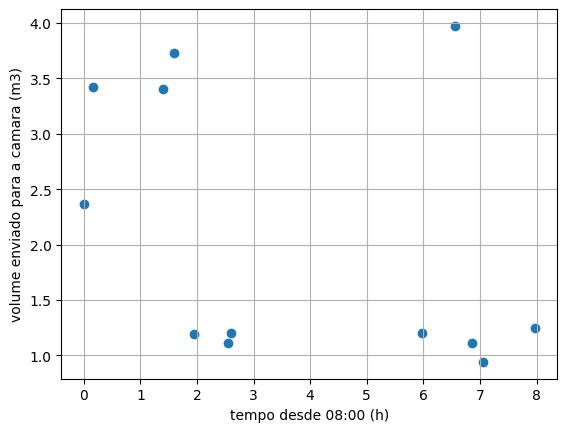

In [5]:
plt.scatter(tempo_chegada,volume_descarga)
plt.xlabel('tempo desde 08:00 (h)')
plt.ylabel('volume enviado para a camara (m3)')
plt.grid(True)
plt.show()

### Monte Carlo

Cada iteracao simula tres dias de operacao. O volume de projeto e estimado pelo percentil 95 dos volumes calculados.

In [6]:
Vpercentil=np.array([])
Vmedia=np.array([])
caminhoesMedios=np.array([])

for rep in range(repeticoes):
    Vcamara=np.array([])
    caminhoesRep=np.array([])

    for i in range(N):
        Vtresdias=0
        caminhoes=0

        for dia in range(dias):
            tempo=0

            u=np.random.uniform(0,1)
            if u<=0.20:
                Vtruck=10
            elif u<=0.40:
                Vtruck=7
            else:
                Vtruck=3

            Esorting=np.random.uniform(5,10)
            Mo=np.random.uniform(60,70)
            Escreening=np.random.uniform(90,95)
            Vi=Vtruck*(1-Esorting/100)*(1-(Mo/100)*(Escreening/100))
            Vtresdias=Vtresdias+Vi
            caminhoes=caminhoes+1

            while tempo<=tempo_operacao:
                p=np.random.uniform(0,1)
                tempo=tempo-np.log(1-p)/taxa_chegada

                if tempo<=tempo_operacao:
                    u=np.random.uniform(0,1)
                    if u<=0.20:
                        Vtruck=10
                    elif u<=0.40:
                        Vtruck=7
                    else:
                        Vtruck=3

                    Esorting=np.random.uniform(5,10)
                    Mo=np.random.uniform(60,70)
                    Escreening=np.random.uniform(90,95)
                    Vi=Vtruck*(1-Esorting/100)*(1-(Mo/100)*(Escreening/100))
                    Vtresdias=Vtresdias+Vi
                    caminhoes=caminhoes+1

        Vchamber=Vtresdias/0.90
        Vcamara=np.append(Vcamara,Vchamber)
        caminhoesRep=np.append(caminhoesRep,caminhoes/dias)

    Vpercentil=np.append(Vpercentil,np.percentile(Vcamara,95))
    Vmedia=np.append(Vmedia,np.mean(Vcamara))
    caminhoesMedios=np.append(caminhoesMedios,np.mean(caminhoesRep))

Vmc=np.mean(Vpercentil)
Vmc_media=np.mean(Vmedia)
caminhoes_medio=np.mean(caminhoesMedios)
erro_tabela=np.abs(Vmc-volume_artigo_tabela)/volume_artigo_tabela*100
erro_resumo=np.abs(Vmc-volume_artigo_resumo)/volume_artigo_resumo*100

print("percentis 95 das repeticoes")
print(Vpercentil)
print("volume MC reproduzido",Vmc)
print("media dos volumes simulados",Vmc_media)
print("media de caminhoes por dia",caminhoes_medio)
print("volume do artigo na tabela",volume_artigo_tabela)
print("volume do artigo no resumo",volume_artigo_resumo)
print("erro relativo contra tabela (%)",erro_tabela)
print("erro relativo contra resumo (%)",erro_resumo)

percentis 95 das repeticoes
[79.13058341 76.52515478 78.2625526  76.54590945 77.90606965 77.27398127
 78.33464911 78.13518428 81.08240939 79.86023791]
volume MC reproduzido 78.30567318478849
media dos volumes simulados 57.51737737670256
media de caminhoes por dia 8.991200000000001
volume do artigo na tabela 94.71
volume do artigo no resumo 94.84
erro relativo contra tabela (%) 17.320585804256687
erro relativo contra resumo (%) 17.4339169287342


### Figura 11 reproduzida

A figura abaixo reproduz a ideia da Figura 11 do artigo: distribuicao dos volumes calculados por Monte Carlo e indicacao do percentil 95.

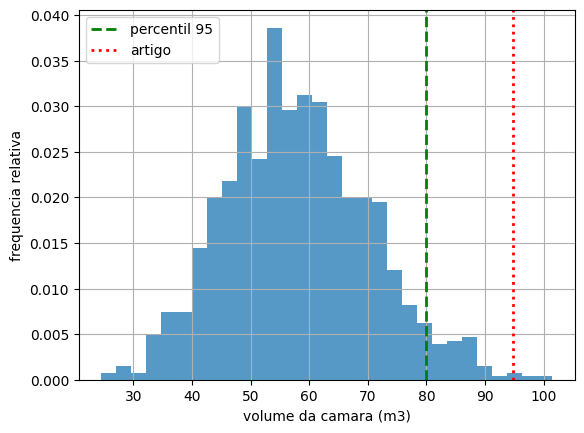

percentil 95 da ultima repeticao 79.86023791156104
figura salva como figura11_reproduzida.png


In [7]:
V95=np.percentile(Vcamara,95)

plt.hist(Vcamara,bins=30,density=True,alpha=0.75)
plt.axvline(V95,color='green',linestyle='--',linewidth=2,label='percentil 95')
plt.axvline(volume_artigo_tabela,color='red',linestyle=':',linewidth=2,label='artigo')
plt.xlabel('volume da camara (m3)')
plt.ylabel('frequencia relativa')
plt.legend()
plt.grid(True)
plt.savefig('figura11_reproduzida.png',dpi=200,bbox_inches='tight')
plt.show()

print("percentil 95 da ultima repeticao",V95)
print("figura salva como figura11_reproduzida.png")

### Comparacao final

O valor de projeto obtido por Monte Carlo deve ser comparado com o resultado reportado no artigo.

In [8]:
print("resultado reproduzido =",Vmc,"m3")
print("resultado do artigo - tabela =",volume_artigo_tabela,"m3")
print("resultado do artigo - resumo =",volume_artigo_resumo,"m3")
print("erro relativo contra a tabela =",erro_tabela,"%")
print("erro relativo contra o resumo =",erro_resumo,"%")

resultado reproduzido = 78.30567318478849 m3
resultado do artigo - tabela = 94.71 m3
resultado do artigo - resumo = 94.84 m3
erro relativo contra a tabela = 17.320585804256687 %
erro relativo contra o resumo = 17.4339169287342 %
